<a href="https://colab.research.google.com/github/ashoktamang002/Foundation-of-Data-Science/blob/main/Assessment%202%20Solution/Analytic%20Task%204/Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIFA World Cup 2026: Goalkeeper Clean Sheets and Save Percentage
This notebook answers the analytical question:
Do goalkeepers who recorded at least one clean sheet have a significantly different average save percentage compared with goalkeepers who recorded no clean sheets?

# 1. Analytical Question and Hypotheses

## Analytic Question

**Do FIFA World Cup 2026 goalkeepers who recorded at least one clean sheet have a significantly different average save percentage compared with goalkeepers who recorded no clean sheets?**

### Motivation

A goalkeeper's save percentage measures the proportion of shots on target that they successfully save, while clean sheets represent matches in which the goalkeeper's team conceded no goals.

This analysis investigates whether these two measures are associated at the goalkeeper level during the FIFA World Cup 2026. The question is non trivial because a goalkeeper's save percentage may reflect not only individual performance but also the defensive environment created by their team.

### Hypotheses

**Null hypothesis (H₀):**  
There is no difference in the mean save percentage between goalkeepers with at least one clean sheet and goalkeepers with no clean sheets.

**Alternative hypothesis (H₁):**  
There is a difference in the mean save percentage between the two groups.

A significance level of **α = 0.05** is used.

In [22]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


# 2. Data Collection
The workbook contains goalkeeper level data on appearances, shots on target faced, saves and clean sheets. Save percentage is calculated during the data wrangling stage using saves and shots on target faced.

Main FBref page: https://fbref.com/en/comps/1/keepers/World-Cup-Stats


The required source fields are Player, MP, SoTA, Saves, and CS.

In [9]:
from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded))
raw_data = pd.read_csv(file_name)
raw_data.head()


Saving Task4_Goalkeeper_stats.csv to Task4_Goalkeeper_stats (3).csv


,Player,MP,SoTA,Saves,CS
0,Yazeed Abulaila,3,16,8,0
1,Mahmoud Abunada,3,22,12,0
2,Alisson,5,18,14,2
3,Benjamin Asare,3,10,8,2
4,Lawrence Ati-Zigi,2,9,8,1


# 3. Data Wrangling and preparation
The goalkeeper dataset was imported from the FIFA World Cup 2026 data source. Only variables relevant to the analytic question were retained.

The analysis uses:

- Goalkeeper
- Matches Played
- Shots on Target Faced
- Total Saves
- Clean Sheets

Save percentage was calculated as:

**Save Percentage = (Total Saves / Shots on Target Faced) × 100**

Goalkeepers without valid save percentage information were excluded because save percentage cannot be meaningfully calculated without shots on target faced.

Goalkeepers who had not played any matches were also excluded.

In [10]:
raw_data.columns

Index(['Player', 'MP', 'SoTA', 'Saves', 'CS'], dtype='object')

In [11]:
df = raw_data[["Player", "MP", "SoTA", "Saves", "CS"]].copy()
df = df.rename(columns={
    "Player": "Goalkeeper",
    "MP": "Games_Played",
    "SoTA": "Shots_On_Target_Faced",
    "Saves": "Saves_Total",
    "CS": "Clean_Sheets"
})

numeric_columns = ["Games_Played", "Shots_On_Target_Faced", "Saves_Total", "Clean_Sheets"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

# A save percentage is not defined if a goalkeeper faced zero shots on target.
df["Save_Percentage"] = np.where(
    df["Shots_On_Target_Faced"] > 0,
    100 * df["Saves_Total"] / df["Shots_On_Target_Faced"],
    np.nan
)

df = df.dropna(subset=["Games_Played", "Clean_Sheets", "Save_Percentage"])
df = df[df["Games_Played"] > 0].copy()
df["Clean_Sheet_Group"] = np.where(
    df["Clean_Sheets"] >= 1,
    "At least one clean sheet",
    "No clean sheets"
)

df.head()

,Goalkeeper,Games_Played,Shots_On_Target_Faced,Saves_Total,Clean_Sheets,Save_Percentage,Clean_Sheet_Group
0,Yazeed Abulaila,3,16,8,0,50.000000,No clean sheets
1,Mahmoud Abunada,3,22,12,0,54.545455,No clean sheets
2,Alisson,5,18,14,2,77.777778,At least one clean sheet
3,Benjamin Asare,3,10,8,2,80.000000,At least one clean sheet
4,Lawrence Ati-Zigi,2,9,8,1,88.888889,At least one clean sheet


In [12]:
print("Final number of goalkeeper records:", len(df))
df.isnull().sum()

Final number of goalkeeper records: 59


,0
Goalkeeper,0
Games_Played,0
Shots_On_Target_Faced,0
Saves_Total,0
Clean_Sheets,0
Save_Percentage,0
Clean_Sheet_Group,0


## 3.1 Data Preparation and Sampling

The dataset was filtered to include only goalkeepers who had participated in at least one match and had valid values for clean sheets and save percentage.

Because the available FIFA World Cup 2026 goalkeeper dataset contains the relevant population of players for this investigation, the analysis uses the available eligible goalkeeper observations rather than drawing an arbitrary smaller subset.

The final sample is divided into two independent groups:

1. **At least one clean sheet**
2. **No clean sheets**

Each goalkeeper contributes one observation to the analysis, preventing a goalkeeper with more matches from being counted multiple times.

In [23]:
# Check the prepared sample

print("Number of eligible goalkeepers:", len(df))
print("\nGroup counts:")
print(df["Clean_Sheet_Group"].value_counts())

print("\nMissing values:")
print(df[
    ["Goalkeeper", "Games_Played", "Clean_Sheets", "Save_Percentage"]
].isna().sum())

Number of eligible goalkeepers: 59

Group counts:
Clean_Sheet_Group
No clean sheets             31
At least one clean sheet    28
Name: count, dtype: int64

Missing values:
Goalkeeper         0
Games_Played       0
Clean_Sheets       0
Save_Percentage    0
dtype: int64


# 4. Descriptive Statistics
The mean describes the average save percentage, the median gives the middle value, and the standard deviation indicates the spread within each group.

In [13]:
group_stats = df.groupby("Clean_Sheet_Group")["Save_Percentage"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
group_stats

,count,mean,median,std,min,max
Clean_Sheet_Group,,,,,,
At least one clean sheet,28,72.370451,72.077922,9.895211,50.0,88.888889
No clean sheets,31,50.694858,55.555556,19.369662,0.0,76.190476


In [14]:
clean_sheet_save_pct = df.loc[
    df["Clean_Sheet_Group"] == "At least one clean sheet", "Save_Percentage"
]
no_clean_sheet_save_pct = df.loc[
    df["Clean_Sheet_Group"] == "No clean sheets", "Save_Percentage"
]

# 5. 95% Confidence Intervals
A 95% confidence interval estimates a plausible range for the true mean save percentage of each group.

In [15]:
def mean_ci_95(values):
    n = values.count()
    mean = values.mean()
    standard_error = values.std(ddof=1) / np.sqrt(n)
    margin_error = stats.t.ppf(0.975, df=n - 1) * standard_error
    return mean, mean - margin_error, mean + margin_error

clean_mean, clean_ci_lower, clean_ci_upper = mean_ci_95(clean_sheet_save_pct)
no_clean_mean, no_clean_ci_lower, no_clean_ci_upper = mean_ci_95(no_clean_sheet_save_pct)

print("At least one clean sheet:")
print("Mean save percentage:", round(clean_mean, 2))
print("95% CI:", round(clean_ci_lower, 2), "to", round(clean_ci_upper, 2))
print()
print("No clean sheets:")
print("Mean save percentage:", round(no_clean_mean, 2))
print("95% CI:", round(no_clean_ci_lower, 2), "to", round(no_clean_ci_upper, 2))

At least one clean sheet:
Mean save percentage: 72.37
95% CI: 68.53 to 76.21

No clean sheets:
Mean save percentage: 50.69
95% CI: 43.59 to 57.8


# 5.1 Visualisation: Average Save Percentage

 The bar chart compares the mean save percentage between goalkeepers with at least one clean sheet and those with no clean sheets. Error bars represent the 95% confidence intervals.

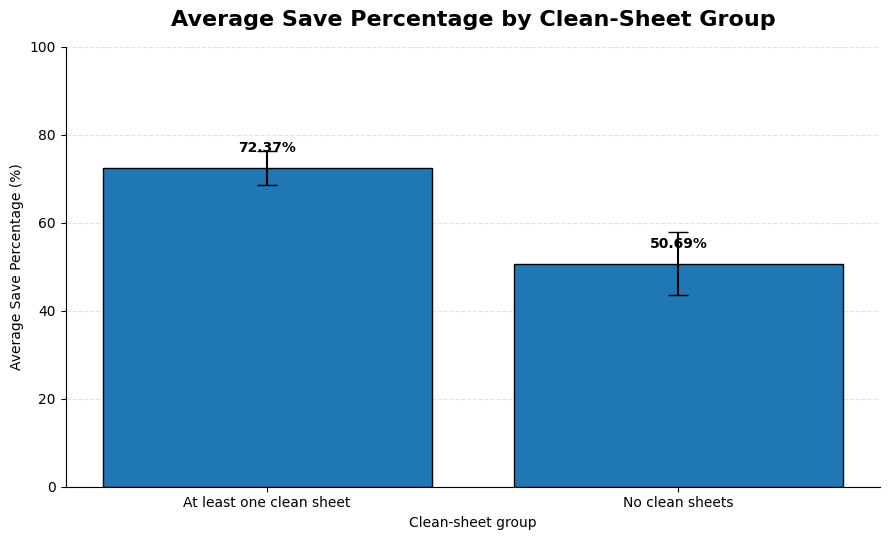

In [25]:
# Prepare data for visualisation
groups = [
    "At least one clean sheet",
    "No clean sheets"
]

means = [
    clean_mean,
    no_clean_mean
]

ci_lower = [
    clean_ci_lower,
    no_clean_ci_lower
]

ci_upper = [
    clean_ci_upper,
    no_clean_ci_upper
]

# Calculate error-bar sizes
lower_error = np.array(means) - np.array(ci_lower)
upper_error = np.array(ci_upper) - np.array(means)

# Create the chart
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    groups,
    means,
    yerr=[lower_error, upper_error],
    capsize=7,
    edgecolor="black"
)

ax.set_title(
    "Average Save Percentage by Clean-Sheet Group",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Clean-sheet group")
ax.set_ylabel("Average Save Percentage (%)")
ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)

# Display mean values
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"{mean:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()




#6.  Statistical Assumption Checks

Before conducting the two sample t-test, the distributions of save percentage were examined.

The main assumptions considered are:

- **Independence:** Each goalkeeper contributes one observation.
- **Continuous outcome:** Save percentage is a numerical measure.
- **Distribution shape:** The distributions within each group should not show severe departures from normality.
- **Outliers:** Extreme observations should be examined because they may disproportionately influence the group means.

Welch's two sample t-test is used because the two groups have different sample sizes and variability. Unlike the pooled variance t-test, Welch's test does not require the two groups to have equal variances.

/tmp/ipykernel_2211/3833939452.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


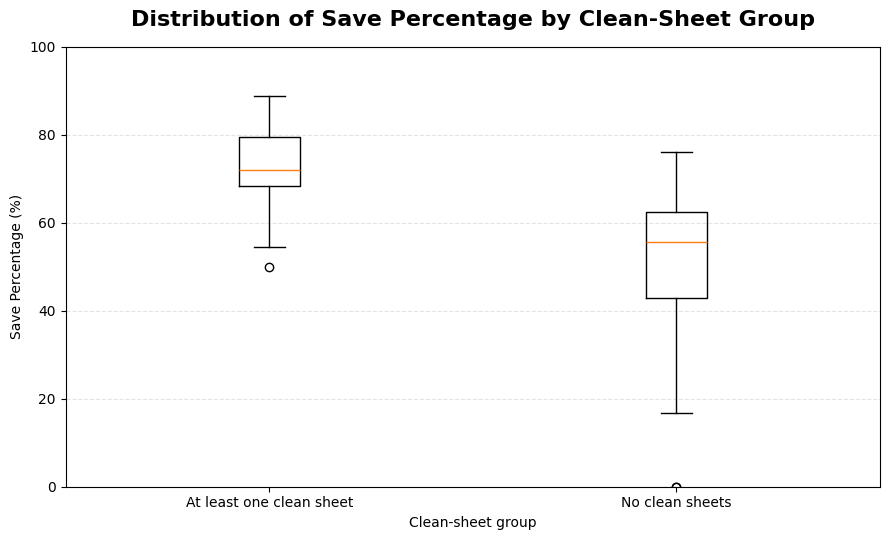

In [26]:
# Examine the distribution of save percentages

fig, ax = plt.subplots(figsize=(9, 5.5))

data_to_plot = [
    clean_sheet_save_pct,
    no_clean_sheet_save_pct
]

ax.boxplot(
    data_to_plot,
    labels=[
        "At least one clean sheet",
        "No clean sheets"
    ]
)

ax.set_title(
    "Distribution of Save Percentage by Clean-Sheet Group",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Clean-sheet group")
ax.set_ylabel("Save Percentage (%)")
ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interpretation of the Distribution

The box plot is used to compare the centre, spread and potential outliers of save percentage between the two clean-sheet groups.

The visualisation provides an additional check of the suitability of comparing the two group means. Any extreme observations should be considered when interpreting the results, as they may have an influence on the calculated means.

The box plot is interpreted alongside the formal normality test rather than being used as the sole basis for assessing the assumptions.

In [27]:
# Shapiro-Wilk normality tests

clean_shapiro = stats.shapiro(clean_sheet_save_pct)
no_clean_shapiro = stats.shapiro(no_clean_sheet_save_pct)

print("At least one clean sheet:")
print("W =", round(clean_shapiro.statistic, 3))
print("p-value =", round(clean_shapiro.pvalue, 4))

print("\nNo clean sheets:")
print("W =", round(no_clean_shapiro.statistic, 3))
print("p-value =", round(no_clean_shapiro.pvalue, 4))

At least one clean sheet:
W = 0.972
p-value = 0.6314

No clean sheets:
W = 0.889
p-value = 0.0038


### Interpretation of Normality Tests



The Shapiro Wilk test showed that the clean sheet group did not significantly depart from normality. However, the no clean sheet group showed evidence of non-normality.

Therefore, the normality assumption should be treated with caution. Welch's two sample t-test is still used as the primary analysis because it is appropriate for comparing two independent groups and does not assume equal variances.

The box plot and descriptive statistics are also considered when interpreting the results.


# 7. Welch's Two Sample t-Test
Welch's t-test is used because the two groups are independent and it does not assume equal variances.

In [17]:
t_statistic, p_value = stats.ttest_ind(
    clean_sheet_save_pct,
    no_clean_sheet_save_pct,
    equal_var=False
)

alpha = 0.05
print("t-statistic:", round(t_statistic, 3))
print("p-value:", round(p_value, 6))

t-statistic: 5.488
p-value: 2e-06


###7.1 Effect Size

In [29]:
# Calculate Cohen's d

mean_difference = (
    clean_sheet_save_pct.mean()
    - no_clean_sheet_save_pct.mean()
)

pooled_sd = np.sqrt(
    (
        (len(clean_sheet_save_pct) - 1) * clean_sheet_save_pct.var(ddof=1)
        +
        (len(no_clean_sheet_save_pct) - 1) * no_clean_sheet_save_pct.var(ddof=1)
    )
    /
    (
        len(clean_sheet_save_pct)
        + len(no_clean_sheet_save_pct)
        - 2
    )
)

cohens_d = mean_difference / pooled_sd

print("Mean difference:", round(mean_difference, 2), "percentage points")
print("Cohen's d:", round(cohens_d, 3))

Mean difference: 21.68 percentage points
Cohen's d: 1.388


Cohen's d is used to measure the magnitude of the difference between the two groups. This complements the p-value because statistical significance does not indicate how large or practically meaningful the difference is.

# 8. Interpretation and Final Conclusion

In [28]:
# Final statistical results and interpretation

print("FINAL RESULTS")
print("=" * 60)

print(
    "At-least-one-clean-sheet group mean save percentage:",
    round(clean_mean, 2), "%"
)

print(
    "At-least-one-clean-sheet group 95% CI:",
    round(clean_ci_lower, 2), "%",
    "to",
    round(clean_ci_upper, 2), "%"
)

print(
    "No-clean-sheets group mean save percentage:",
    round(no_clean_mean, 2), "%"
)

print(
    "No-clean-sheets group 95% CI:",
    round(no_clean_ci_lower, 2), "%",
    "to",
    round(no_clean_ci_upper, 2), "%"
)

mean_difference = clean_mean - no_clean_mean

print(
    "Difference in group means:",
    round(mean_difference, 2),
    "percentage points"
)

print(
    "Welch t-test statistic:",
    round(t_statistic, 3)
)

print(
    "Welch t-test p-value:",
    round(p_value, 6)
)

print("\nSTATISTICAL DECISION")
print("=" * 60)

if p_value < alpha:

    print("Decision: Reject H0.")

    print(
        "There is statistically significant evidence that "
        "the average save percentage differs between the two groups."
    )

    print(
        f"The at-least-one-clean-sheet group had a higher average "
        f"save percentage by {mean_difference:.2f} percentage points."
    )

else:

    print("Decision: Fail to reject H0.")

    print(
        "There is insufficient statistical evidence to conclude "
        "that the average save percentage differs between the two groups."
    )

FINAL RESULTS
At-least-one-clean-sheet group mean save percentage: 72.37 %
At-least-one-clean-sheet group 95% CI: 68.53 % to 76.21 %
No-clean-sheets group mean save percentage: 50.69 %
No-clean-sheets group 95% CI: 43.59 % to 57.8 %
Difference in group means: 21.68 percentage points
Welch t-test statistic: 5.488
Welch t-test p-value: 2e-06

STATISTICAL DECISION
Decision: Reject H0.
There is statistically significant evidence that the average save percentage differs between the two groups.
The at-least-one-clean-sheet group had a higher average save percentage by 21.68 percentage points.

INTERPRETATION
Goalkeepers with at least one clean sheet had an average save percentage of 72.37%, compared with 50.69% for goalkeepers with no clean sheets.
This represents a difference of approximately 21.68 percentage points.
The 95% confidence intervals provide additional evidence of a difference between the estimated group means.
However, statistical significance should not be interpreted as evide

## Interpretation of Results

The descriptive results show a substantial difference in save percentage between the two groups.

Goalkeepers with at least one clean sheet recorded an average save percentage of **72.37%**, compared with **50.69%** for goalkeepers with no clean sheets. This represents a difference of approximately **21.68 percentage points**.

The 95% confidence interval for the clean-sheet group was **68.53% to 76.21%**, while the confidence interval for the no-clean-sheet group was **43.59% to 57.80%**.

The Welch two-sample t-test produced a **t-statistic of 5.488** and a **p-value of approximately 0.000002**. Since the p-value is substantially below the significance level of **α = 0.05**, the null hypothesis is rejected.

Therefore, there is statistically significant evidence that the mean save percentage differs between goalkeepers with at least one clean sheet and those with no clean sheets. In this dataset, the clean-sheet group recorded the higher average save percentage.

However, this result demonstrates an **association rather than causation**. A clean sheet does not necessarily cause a goalkeeper to have a higher save percentage. Other factors, such as team defensive strength, opposition quality, shot difficulty and goalkeeper playing time, may contribute to the observed relationship.

## Limitations

Several limitations should be considered when interpreting the findings.

- **Association does not imply causation:** The analysis identifies a relationship between clean-sheet status and save percentage but does not establish a causal relationship.

- **Team defensive strength:** Goalkeepers operate within different defensive systems, which can affect the number and quality of shots they face.

- **Opposition quality:** Differences in opponent strength may influence both shots on target and goalkeeper performance.

- **Sample size:** The analysis contains a relatively small number of World Cup goalkeepers, which limits the generalisability of the findings.

- **Save percentage is not a complete measure of goalkeeper performance:** It does not account for factors such as shot difficulty, positioning, distribution or defensive organisation.

- **Tournament-specific context:** The results are based on FIFA World Cup 2026 data and may not generalise to domestic leagues, other tournaments or different seasons.